<!-- NINO26-CABECALHO v1 -->
# 3C — Precursores: o que antecede o pico do Niño 3.4?

**Projeto NINO-BRASIL — Oceanografia Física UFPE — Thiago Vilar**  
**Código da fase/letra:** `3C`  ·  **Hipótese:** HIP0

## Descritivo (por que este notebook existe)
Constrói o ranking preliminar de precursores do aquecimento máximo — o teste direto do paradigma de recarga (WWV/OHC/D20 liderando o SSTA).

## Pergunta
Quais variáveis físicas lideram a SSTA do Niño 3.4 e em que defasagem semanal?

## Desafio (hipótese a testar)
Separar precursor verdadeiro (lidera com antecedência) de estado contemporâneo; o sinal de recarga deve anteceder o pico por semanas.

## Metodologia (com referências)
Correlação defasada preditor(t-lag)->SSTA(t) e ranking por lag, antes dos filtros de rigor do 3D/3E (paradigma de recarga de Jin, 1997; Meinen & McPhaden, 2000).

## Contrato de saídas — código predecessor único
Cada figura nasce do **mesmo** `registrar_figura(...)` que congela sua numeric-table sob o **mesmo código**, reescrevendo por **sobreposição** a cada execução. A fonte deve ser uma tabela persistida com sidecar e hash do mesmo `run_id`:

```python
from nino_brasil.viz import registrar_figura
registrar_figura(fig, "Fig_3C01", fase=3, bloco="C",
                 titulo=..., descricao=..., hipotese="HIP0",
                 notebook="notebooks/fase3/3C_precursores_lags.ipynb",
                 run_id=run.run_id,
                 fontes={"<tabela>": tabela_path})   # Path + .manifest.json -> figures/fase3/<codigo>.png + numeric-tables/fase3/<codigo>/
```

| Código | Figura (`figures/fase3/<código>.png`) | Numeric-table (`numeric-tables/fase3/<código>/`) | Descrição |
|---|---|---|---|
| `Fig_3C01` | `Fig_3C01.png` | `Fig_3C01/` | heatmap de correlação por lag |
| `Fig_3C02` | `Fig_3C02.png` | `Fig_3C02/` | mapa longitude x lag |

> Padrão em `docs/PADRAO_NOTEBOOKS.md`; compatibilidade por `python scripts/validar_figuras.py --strict --allow-render-extraction`; promoção por `python scripts/validar_figuras.py --strict`.

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase3_utils as u
from nino_brasil.stats.phase3_inference import PRECURSOR_TARGET_EXCLUSION_POLICY, is_phase3_target_alias, phase3_precursor_columns
w_raw=pd.read_csv(u.DERIVED_FEAT/'phase3_indices_semanais.csv',parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
w, preprocessing_contract = u.diagnostic_predictor_transform(w_raw)
EVALUATION_MODE='diagnostico_retrospectivo_inferencial'
TARGET='nino34_ssta'; tgt=w[TARGET]; COMMON='1993-01-01'; LAGS=range(0,79)
preds, excluded_target_aliases = phase3_precursor_columns(w.columns, selected_signal=TARGET)
preds=list(preds); N_PRECURSORS=len(preds); EXCLUDED_TARGET_ALIASES='|'.join(excluded_target_aliases)
assert TARGET in excluded_target_aliases and N_PRECURSORS > 0
assert not any(is_phase3_target_alias(v, selected_signal=TARGET) for v in preds)
screening_catalogue=pd.DataFrame([{'variavel_alvo':TARGET,'n_precursores_candidatos':N_PRECURSORS,'aliases_alvo_excluidos':EXCLUDED_TARGET_ALIASES,'precursor_screening_policy':PRECURSOR_TARGET_EXCLUSION_POLICY,'precursores_candidatos':'|'.join(preds)}])
u.save_table(screening_catalogue, 'phase3C_precursor_screening.csv', index=False)
def lcf(df,tg,lags): return pd.DataFrame({c:{lag:tg.corr(df[c].shift(lag)) for lag in lags} for c in df.columns})
lc=lcf(w.loc[COMMON:,preds],tgt.loc[COMMON:],LAGS)
u.save_table(lc.rename_axis('lag_semanas'), 'phase3C_lag_correlacoes.csv')
print(f'Correlacoes defasadas (1993+) para {N_PRECURSORS} precursores; alvo/aliases excluidos: {EXCLUDED_TARGET_ALIASES}')

[tabela semântica] data\processed\parquet\statistics\phase3C_precursor_screening.csv


[tabela semântica] data\processed\parquet\statistics\phase3C_lag_correlacoes.csv
Correlacoes defasadas (1993+) para 30 precursores; alvo/aliases excluidos: nino34_ssta


In [2]:
rank = pd.DataFrame({'r_max_abs': lc.abs().max(), 'lag_do_max_semanas': lc.abs().idxmax()})
rank['r_no_lag_max'] = [round(lc.loc[l, v], 3) for v, l in zip(rank.index, rank['lag_do_max_semanas'])]
rank['sinal'] = np.where(rank['r_no_lag_max'] >= 0, 'positivo', 'negativo')
rank['variavel_alvo'] = TARGET
rank['n_precursores_candidatos'] = N_PRECURSORS
rank['aliases_alvo_excluidos'] = EXCLUDED_TARGET_ALIASES
rank['precursor_screening_policy'] = PRECURSOR_TARGET_EXCLUSION_POLICY
rank['leitura'] = rank.apply(lambda r: f"{u.var_label(r.name, short=True)} antecede SSTA em {int(r['lag_do_max_semanas'])} semanas (r={r['r_no_lag_max']:+.2f})", axis=1)
rank = rank.sort_values('r_max_abs', ascending=False)
u.save_table(rank, 'phase3C_ranking_lags.csv')
print('Ranking bruto por maior |r| (antes de N_eff/FDR):')
print(rank[['r_max_abs','lag_do_max_semanas','r_no_lag_max','leitura']].to_string())


[tabela semântica] data\processed\parquet\statistics\phase3C_ranking_lags.csv
Ranking bruto por maior |r| (antes de N_eff/FDR):
                      r_max_abs  lag_do_max_semanas  r_no_lag_max                                             leitura
t50m                   0.932593                   0         0.933           t50m antecede SSTA em 0 semanas (r=+0.93)
ohc_0_100              0.918571                   2         0.919      ohc_0_100 antecede SSTA em 2 semanas (r=+0.92)
tilt_m                 0.883661                   0         0.884           Tilt antecede SSTA em 0 semanas (r=+0.88)
ssh_m                  0.850750                   6         0.851            SSH antecede SSTA em 6 semanas (r=+0.85)
ohc_0_300              0.830283                   7         0.830       OHC0-300 antecede SSTA em 7 semanas (r=+0.83)
ohc_0_700              0.821374                   6         0.821       OHC0-700 antecede SSTA em 6 semanas (r=+0.82)
t100m                  0.803140               

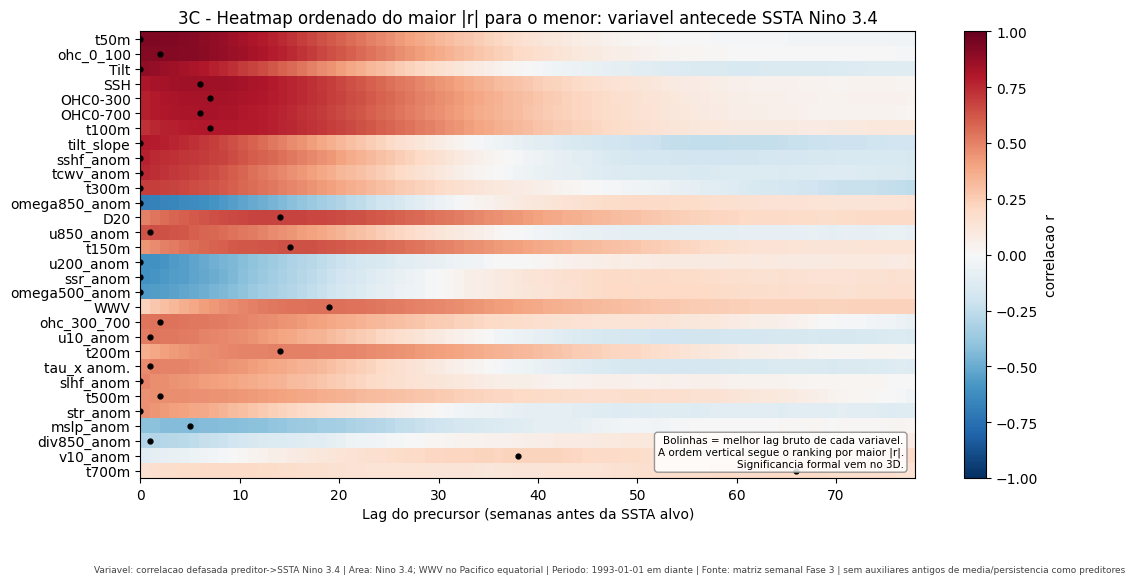

In [3]:
fig, ax = plt.subplots(figsize=(12.5, 5.8))
cols = rank.index.tolist()
mat = lc[cols].T.values
im = ax.imshow(mat, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1, extent=[min(LAGS), max(LAGS), len(cols)-0.5, -0.5])
ax.set_yticks(range(len(cols)))
ax.set_yticklabels([u.var_label(c, short=True) for c in cols])
ax.set_xlabel('Lag do precursor (semanas antes da SSTA alvo)')
ax.set_title('3C - Heatmap ordenado do maior |r| para o menor: variavel antecede SSTA Nino 3.4')
fig.colorbar(im, ax=ax, label='correlacao r')
for y, c in enumerate(cols):
    lag = int(rank.loc[c, 'lag_do_max_semanas'])
    ax.plot(lag, y, 'ko', ms=3.5)
u.add_note(ax, 'Bolinhas = melhor lag bruto de cada variavel.\nA ordem vertical segue o ranking por maior |r|.\nSignificancia formal vem no 3D.', loc='lower right')
u.stamp_caption(fig, variavel='correlacao defasada preditor->SSTA Nino 3.4', area='Nino 3.4; WWV no Pacifico equatorial', periodo=f'{COMMON} em diante', fonte='matriz semanal Fase 3', extra='sem auxiliares antigos de media/persistencia como preditores')
u.save_fig(fig, '3C1_heatmap_lags.png', fontes={'correlacoes': 'phase3C_lag_correlacoes.csv', 'ranking': 'phase3C_ranking_lags.csv', 'screening': 'phase3C_precursor_screening.csv'})
plt.show()


[tabela semântica] data\processed\parquet\statistics\phase3C_mapa_lon_lag.csv


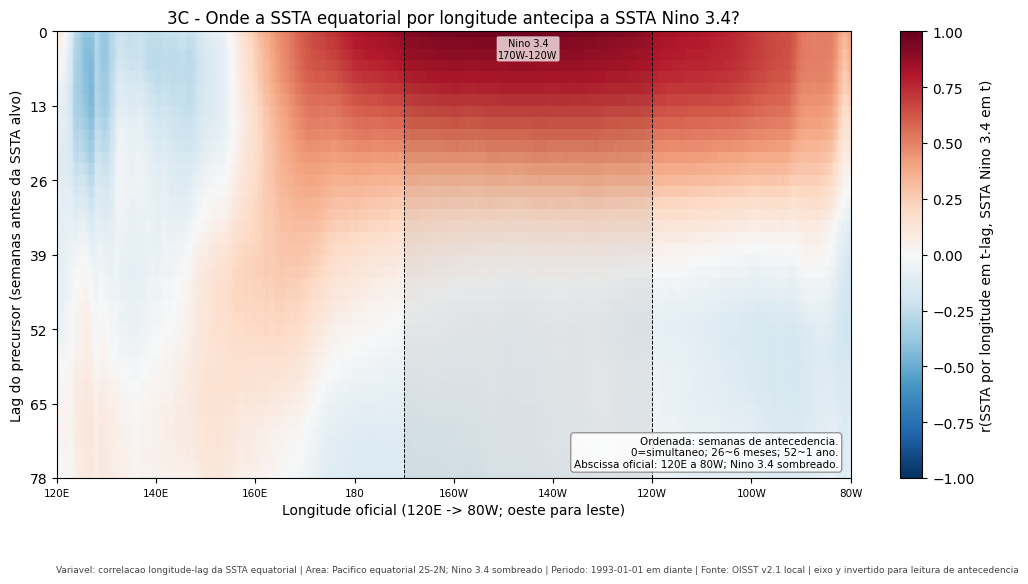

In [4]:
eq = u.load_eqband_weekly().loc[COMMON:]
t = tgt.loc[COMMON:]
eqa, ta = eq.align(t, join='inner', axis=0)
tv = ta.values
lags = list(range(0, 79, 2))
ll = np.full((len(lags), eqa.shape[1]), np.nan)
for i, l in enumerate(lags):
    if l == 0:
        X, y = eqa.values, tv
    else:
        X, y = eqa.iloc[:-l].values, tv[l:]
    ym = y - np.nanmean(y)
    for j in range(X.shape[1]):
        x = X[:, j]
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() > 30:
            xx = x[m] - np.nanmean(x[m])
            yy = ym[m]
            den = np.sqrt(np.sum(xx**2) * np.sum(yy**2))
            ll[i, j] = np.sum(xx*yy)/den if den else np.nan
lon = eqa.columns.values.astype(float)
mapa = pd.DataFrame(ll, index=lags, columns=lon).rename_axis('lag_semanas').stack().rename('r').rename_axis(index=['lag_semanas','longitude_e']).reset_index()
u.save_table(mapa, 'phase3C_mapa_lon_lag.csv', index=False, inputs=(u.FEAT/'equatorial_pacific_ssta_weekly_by_lon.parquet',))
fig, ax = plt.subplots(figsize=(12.8, 5.8))
pc = ax.pcolormesh(lon, lags, ll, cmap='RdBu_r', vmin=-1, vmax=1, shading='auto')
u.add_nino34_lon_band(ax)
u.format_lon_axis(ax)
u.format_lag_axis(ax, max_lag=max(lags))
ax.set_title('3C - Onde a SSTA equatorial por longitude antecipa a SSTA Nino 3.4?')
fig.colorbar(pc, ax=ax, label='r(SSTA por longitude em t-lag, SSTA Nino 3.4 em t)')
u.add_note(ax, 'Ordenada: semanas de antecedencia.\n0=simultaneo; 26~6 meses; 52~1 ano.\nAbscissa oficial: 120E a 80W; Nino 3.4 sombreado.', loc='lower right')
u.stamp_caption(fig, variavel='correlacao longitude-lag da SSTA equatorial', area='Pacifico equatorial 2S-2N; Nino 3.4 sombreado', periodo=f'{COMMON} em diante', fonte='OISST v2.1 local', extra='eixo y invertido para leitura de antecedencia')
u.save_fig(fig, '3C2_mapa_lon_lag.png', fontes={'mapa_longitude_lag': 'phase3C_mapa_lon_lag.csv'})
plt.show()


**Leitura do 3C.** O ranking preliminar (ver saida numerica) e liderado pelo bloco de recarga - **tilt (lag 0), SSH/OHC (~6 sem), D20 (~15 sem), WWV (~20 sem)** - todos series do Nino 3.4 exceto WWV (Pac. equatorial). O mapa lon x lag mostra a inclinacao oeste->leste: anomalias no Pacifico central-oeste antecedem a caixa Nino 3.4, coerente com Kelvin/adveccao. **Nada aqui e significancia** - isso e 3D.

<!-- NINO26-REFERENCIAS v1 -->
## Referências Bibliográficas

1. Jin, F.-F. (1997). An Equatorial Ocean Recharge Paradigm for ENSO. Part I. *J. Atmos. Sci.*, 54, 811-829. https://doi.org/10.1175/1520-0469(1997)054<0811:AEORPF>2.0.CO;2
2. Meinen, C. S., & McPhaden, M. J. (2000). Observations of Warm Water Volume Changes... *J. Climate*, 13, 3551-3559. https://doi.org/10.1175/1520-0442(2000)013<3551:OOWWVC>2.0.CO;2

Relação completa em `Artigos_Referências/Referências_Bibliográficas.xls`.